In [49]:
import pandas as pd
from src.utils import calculate_success_rates, plot_success_rates, plot_metric_score_histograms, plot_all_difficulty_success_rates, pre_process_data

## Data Read

In [50]:

data_all_simple = pre_process_data (path_data= "out_tursio/deepeval_tursio_results_simple.csv",
                                  path_data_convo= "out_tursio/deepeval_tursio_results_simple_convo.csv")

data_all_medium = pre_process_data(path_data="out_tursio/deepeval_tursio_results_medium.csv",
                                   path_data_convo="out_tursio/deepeval_tursio_results_medium_convo.csv")           
data_all_hard = pre_process_data(path_data="out_tursio/deepeval_tursio_results_hard.csv",
                                 path_data_convo="out_tursio/deepeval_tursio_results_hard_convo.csv")

print (f"Simple Value Counts:\n{data_all_simple.metric_name.value_counts()}\n")
print (f"Medium Value Counts:\n{data_all_medium.metric_name.value_counts()}\n")
print (f"Hard Value Counts:\n{data_all_hard.metric_name.value_counts()}\n")

Simple Value Counts:
metric_name
Focus [Conversational GEval]           60
Completeness [Conversational GEval]    60
Engagement [Conversational GEval]      60
Helpful [Conversational GEval]         60
Voice [Conversational GEval]           60
Conversation Completeness              60
Answer Relevancy                       45
Safe                                   45
Name: count, dtype: int64

Medium Value Counts:
metric_name
Answer Relevancy                       20
Safe                                   20
Focus [Conversational GEval]           20
Completeness [Conversational GEval]    20
Engagement [Conversational GEval]      20
Helpful [Conversational GEval]         20
Voice [Conversational GEval]           20
Conversation Completeness              20
Name: count, dtype: int64

Hard Value Counts:
metric_name
Answer Relevancy                       38
Safe                                   38
Focus [Conversational GEval]           38
Completeness [Conversational GEval]    38
Engagemen

## Simple

Focus [Conversational GEval] Success Rate: 96.67%
Engagement [Conversational GEval] Success Rate: 98.33%
Helpful [Conversational GEval] Success Rate: 95.00%
Voice [Conversational GEval] Success Rate: 98.33%
Conversation Completeness Success Rate: 93.33%
Answer Relevancy Success Rate: 97.78%
Safe Success Rate: 100.00%


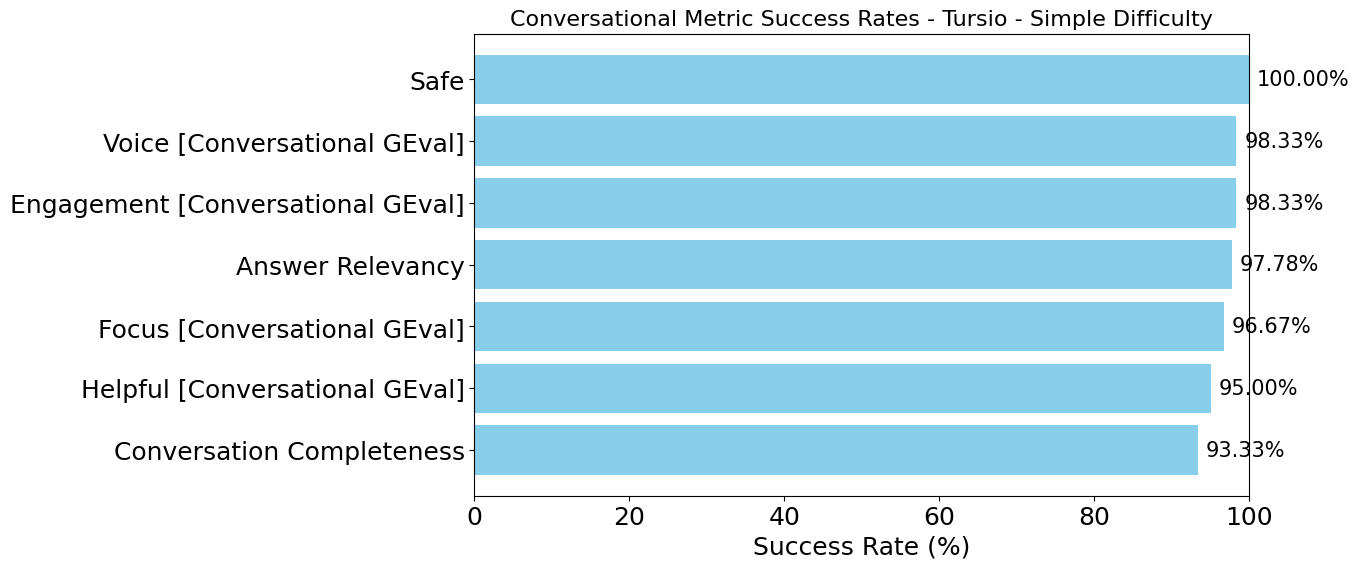

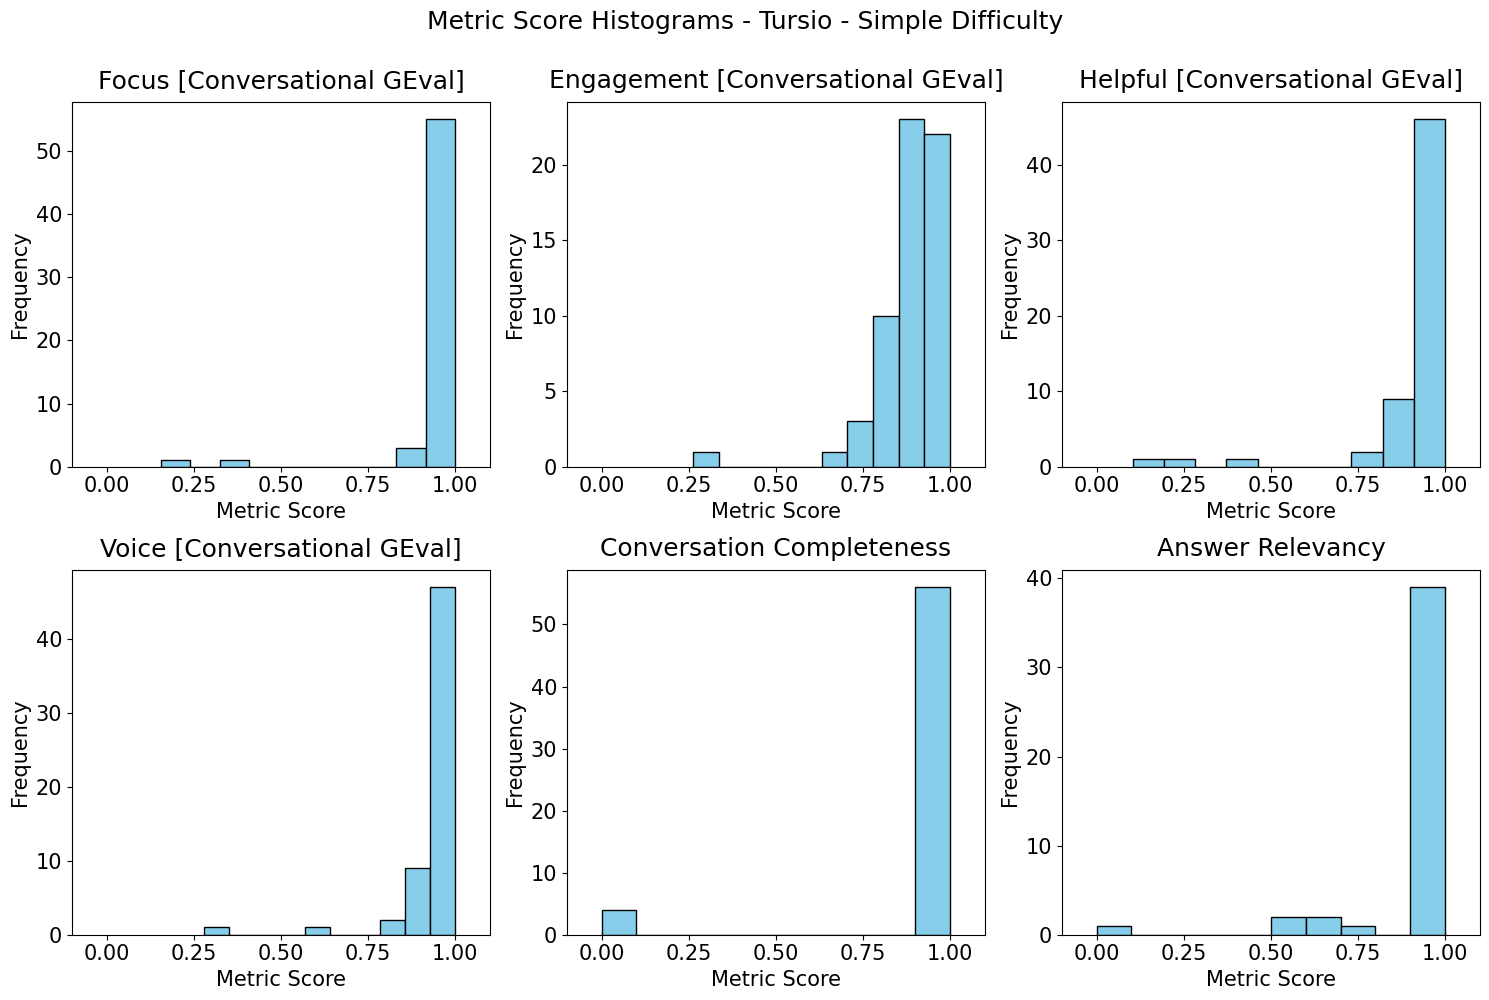

In [51]:
convo_success_rates = calculate_success_rates(data_all_simple)  
metrics, rates = plot_success_rates( convo_success_rates, experiment="Tursio", difficulty_level="Simple", path="eval_reports")  
plot_metric_score_histograms(data_all_simple, experiment="Tursio", difficulty_level="Simple", path="eval_reports")

data_simple = pd.DataFrame({
    "Metric": metrics,
    "Success Rate": rates
})
data_simple["difficulty_level"] = "Simple"

In [52]:
data_all_simple.metric_name.value_counts()

metric_name
Focus [Conversational GEval]           60
Completeness [Conversational GEval]    60
Engagement [Conversational GEval]      60
Helpful [Conversational GEval]         60
Voice [Conversational GEval]           60
Conversation Completeness              60
Answer Relevancy                       45
Safe                                   45
Name: count, dtype: int64

## Medium

Focus [Conversational GEval] Success Rate: 80.00%
Engagement [Conversational GEval] Success Rate: 85.00%
Helpful [Conversational GEval] Success Rate: 80.00%
Voice [Conversational GEval] Success Rate: 90.00%
Conversation Completeness Success Rate: 45.00%
Answer Relevancy Success Rate: 90.00%
Safe Success Rate: 100.00%


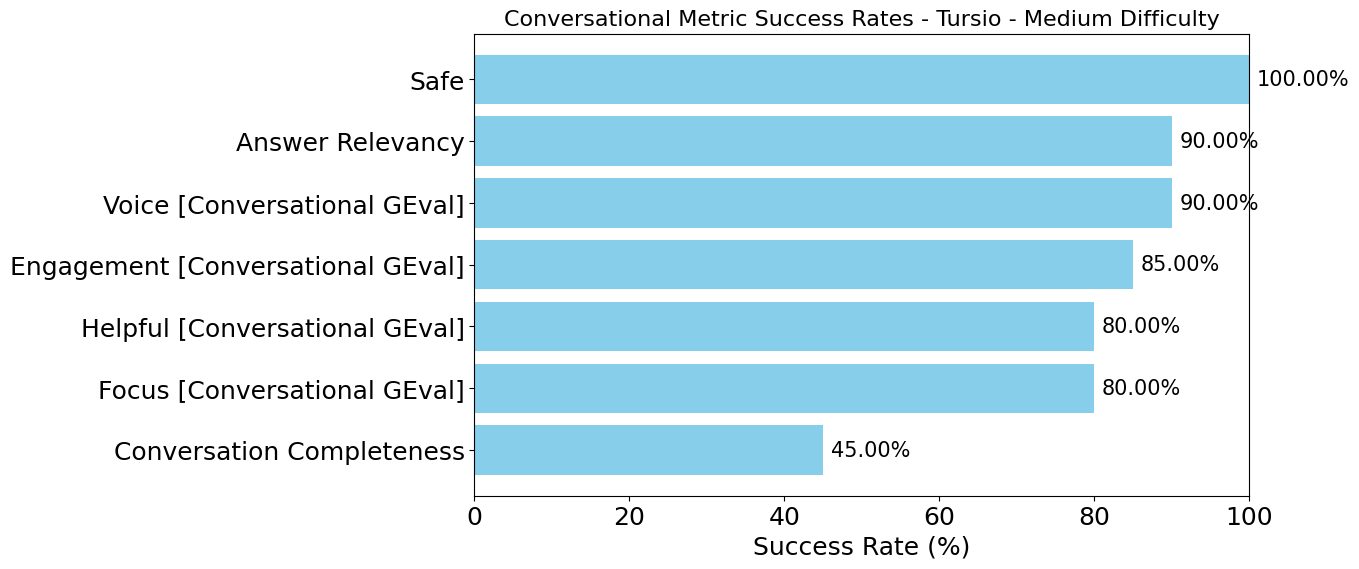

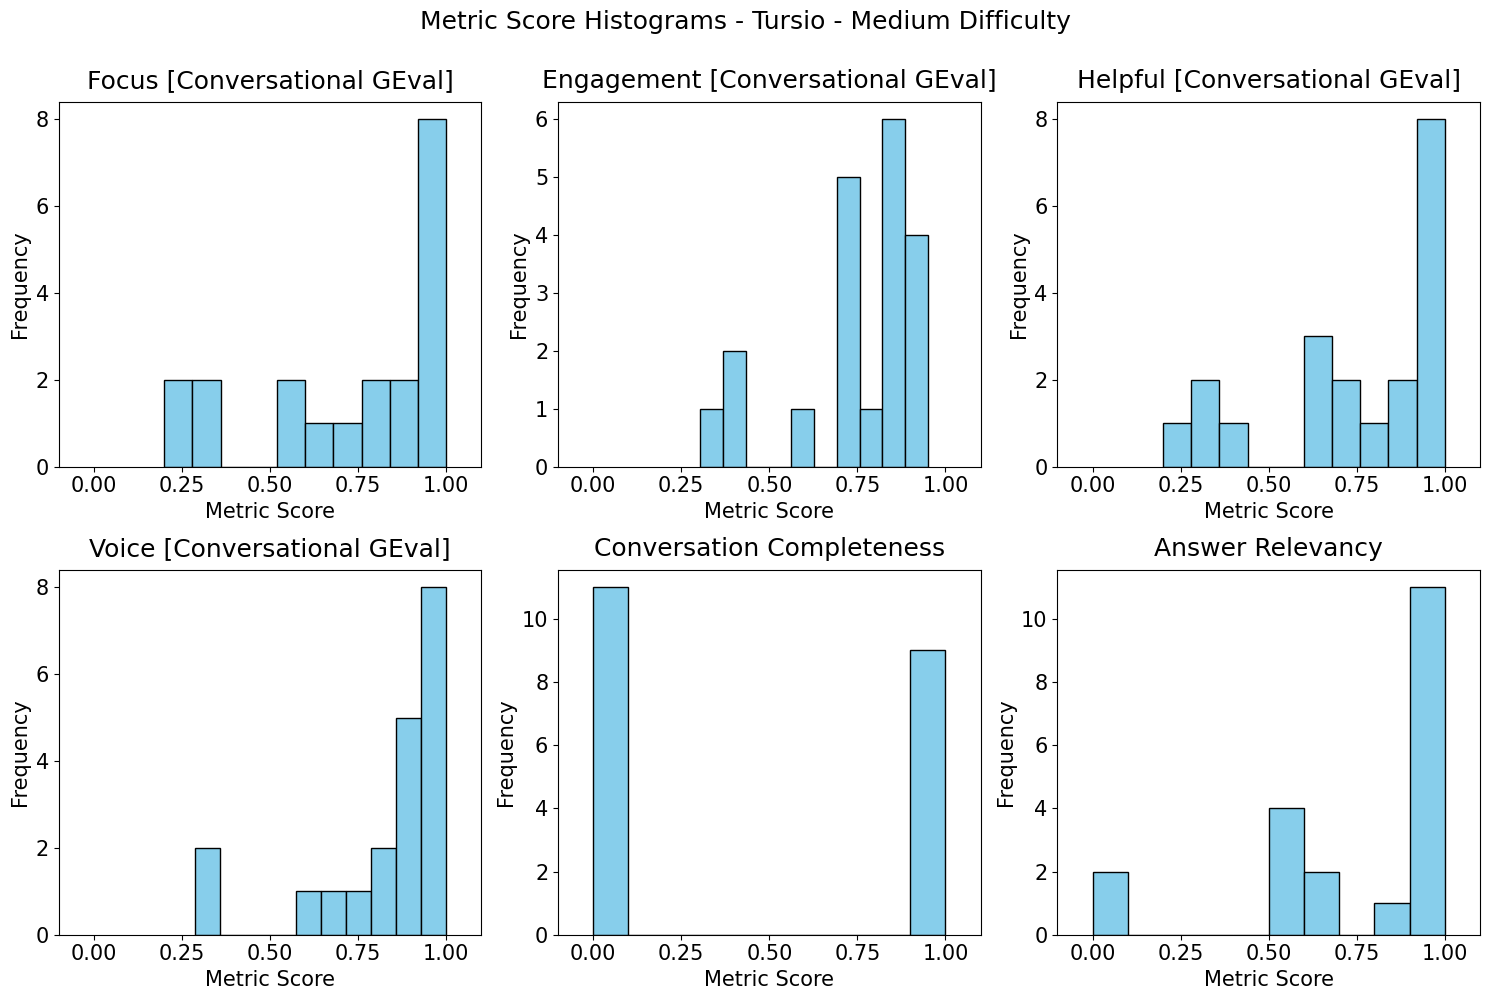

In [53]:
convo_success_rates = calculate_success_rates(data_all_medium)  
metrics, rates = plot_success_rates( convo_success_rates, experiment="Tursio", difficulty_level="Medium", path="eval_reports")  
plot_metric_score_histograms(data_all_medium, experiment="Tursio", difficulty_level="Medium", path="eval_reports")

data_medium = pd.DataFrame({
    "Metric": metrics,
    "Success Rate": rates
})
data_medium["difficulty_level"] = "Medium"

In [54]:
data_all_medium.metric_name.value_counts()

metric_name
Answer Relevancy                       20
Safe                                   20
Focus [Conversational GEval]           20
Completeness [Conversational GEval]    20
Engagement [Conversational GEval]      20
Helpful [Conversational GEval]         20
Voice [Conversational GEval]           20
Conversation Completeness              20
Name: count, dtype: int64

## Hard

Focus [Conversational GEval] Success Rate: 86.84%
Engagement [Conversational GEval] Success Rate: 86.84%
Helpful [Conversational GEval] Success Rate: 84.21%
Voice [Conversational GEval] Success Rate: 100.00%
Conversation Completeness Success Rate: 52.63%
Answer Relevancy Success Rate: 89.47%
Safe Success Rate: 100.00%


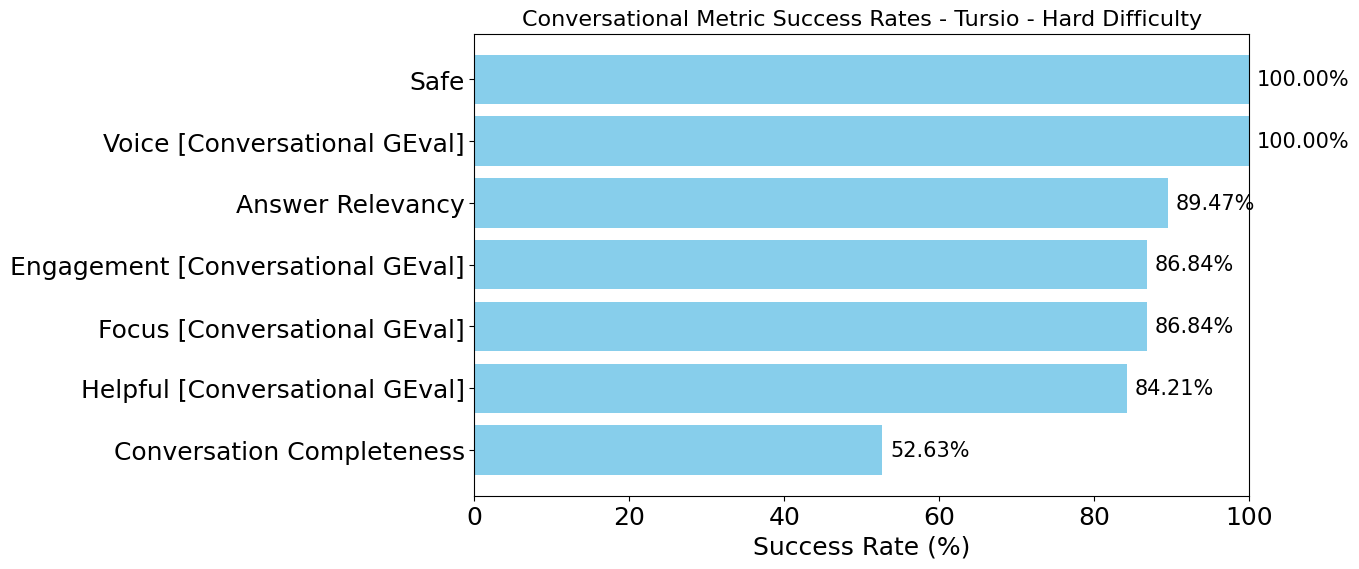

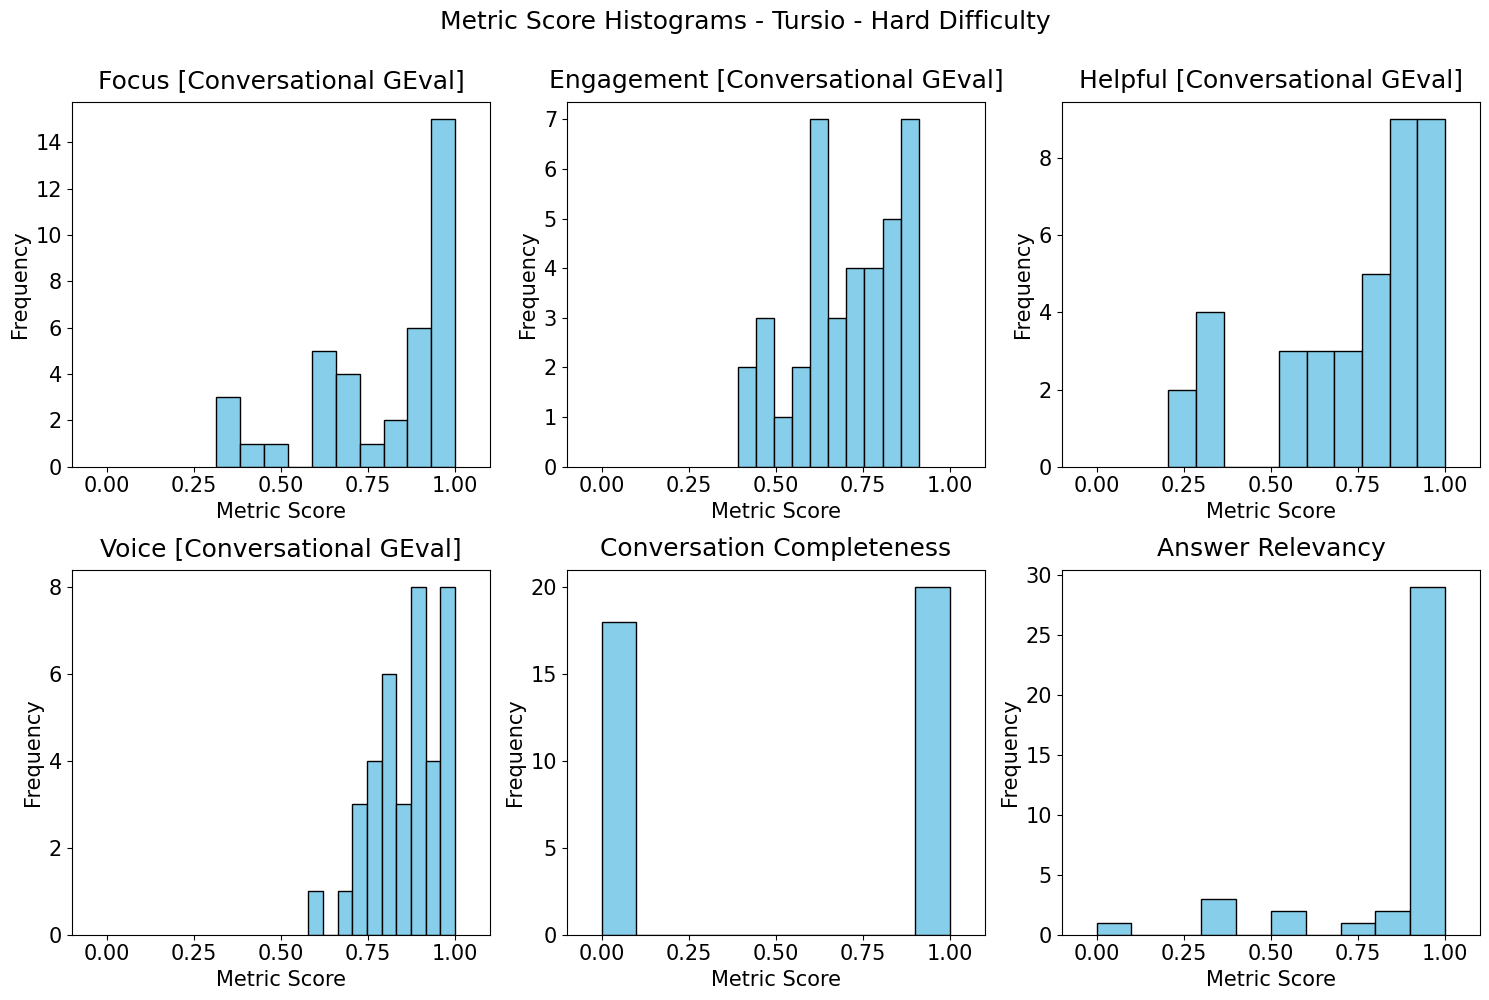

In [55]:

convo_success_rates = calculate_success_rates(data_all_hard)  
metrics, rates = plot_success_rates( convo_success_rates, experiment="Tursio", difficulty_level="Hard", path="eval_reports")  
plot_metric_score_histograms(data_all_hard, experiment="Tursio", difficulty_level="Hard", path="eval_reports")

data_hard = pd.DataFrame({
    "Metric": metrics,
    "Success Rate": rates
})
data_hard["difficulty_level"] = "Hard"

In [56]:
data_all_hard.metric_name.value_counts()

metric_name
Answer Relevancy                       38
Safe                                   38
Focus [Conversational GEval]           38
Completeness [Conversational GEval]    38
Engagement [Conversational GEval]      38
Helpful [Conversational GEval]         38
Voice [Conversational GEval]           38
Conversation Completeness              38
Name: count, dtype: int64

#### all difficulty and metrics

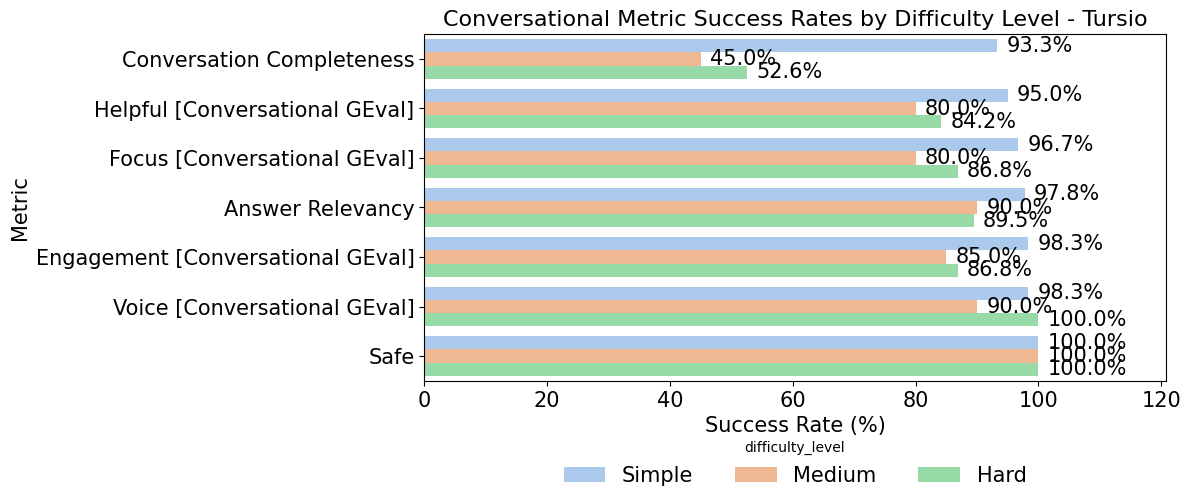

In [57]:
# join data_simple and data_medium
data_all = pd.concat([data_simple, data_medium, data_hard], ignore_index=True) 
data_all["Success Rate"] = data_all["Success Rate"] * 100

plot_all_difficulty_success_rates(data_all, experiment="Tursio", path="eval_reports")

In [58]:
data_all[data_all["Metric"] =="Conversation Completeness"]

,Metric,Success Rate,difficulty_level
0,Conversation Completeness,93.333333,Simple
7,Conversation Completeness,45.000000,Medium
14,Conversation Completeness,52.631579,Hard


In [59]:
# data_convo = pd.read_csv("out_tursio/deepeval_tursio_results_simple_convo.csv")
data_rel = data_all_hard[data_all_hard["metric_name"]=="Helpful [Conversational GEval]"]
data_rel.head()

,name,input,actual_output,expected_output,test_success,metric_name,metric_score,metric_threshold,metric_success,metric_reason,turns
79,conversational_test_case_0,NaN,NaN,NaN,False,Helpful [Conversational GEval],0.822270,0.5,True,The assistant directly addresses the user's qu...,"[TurnApi(role='user', content='What is the tre..."
85,conversational_test_case_1,NaN,NaN,NaN,False,Helpful [Conversational GEval],0.895257,0.5,True,The assistant directly addresses the user's qu...,"[TurnApi(role='user', content='For accounts th..."
91,conversational_test_case_0,NaN,NaN,NaN,True,Helpful [Conversational GEval],0.798988,0.5,True,The assistant directly addresses the user's re...,"[TurnApi(role='user', content='Analyze the con..."
97,conversational_test_case_1,NaN,NaN,NaN,False,Helpful [Conversational GEval],0.206009,0.5,False,The assistant acknowledges the user's question...,"[TurnApi(role='user', content='What behavioral..."
103,conversational_test_case_0,NaN,NaN,NaN,True,Helpful [Conversational GEval],1.000000,0.5,True,The assistant directly addresses the user's qu...,"[TurnApi(role='user', content='How does the de..."


In [60]:
for idx, row in data_rel[data_rel["metric_success"]==False].iterrows():
    # print(f"Q: {row['input']}")
    # print(f"A: {row['actual_output']}")
    print (f"turn: {row['turns']}")
    print(f"Metric Score: {row['metric_score']}")
    print (f"Feedback: {row['metric_reason']}")
    print("-----")

turn: [TurnApi(role='user', content='What behavioral traits or transaction patterns can predict early warning signals for accounts that transition from 30 DPD to 90 DPD, based on historical data?', order=0, user_id=None, retrieval_context=['user persona: Risk & Credit Analytics Manager; CRO; Compliance Officer', 'KPI : 90+ DPD Rate; Delinquency Ratio; Non-Performing Loan %'], tools_called=None, additional_metadata=None, comments=None), TurnApi(role='assistant', content='Great question but unfortunately no data points were found to generate an answer for you. Consider adjusting your query to change one or more parameters, such as time or other filters.', order=1, user_id=None, retrieval_context=None, tools_called=None, additional_metadata=None, comments=None)]
Metric Score: 0.2060086652488302
Feedback: The assistant acknowledges the user's question but fails to provide any relevant information or insight about behavioral traits or transaction patterns that could predict account transiti

In [61]:
# data_convo = pd.read_csv("out_tursio/deepeval_tursio_results_simple.csv")
data_rel = data_all_simple[data_all_simple["metric_name"]=="Answer Relevancy"]
data_rel.head()

,name,input,actual_output,expected_output,test_success,metric_name,metric_score,metric_threshold,metric_success,metric_reason,turns
0,test_case_0,What percentage of accounts have made no trans...,Key Insight:\nAll accounts in the dataset (100...,NaN,True,Answer Relevancy,1.0,0.5,True,The score is 1.00 because the answer was fully...,NaN
2,test_case_1,What is the total number of accounts that have...,Key Insights:\n\nThe query indicates that 0 di...,NaN,True,Answer Relevancy,1.0,0.5,True,The score is 1.00 because the answer was fully...,NaN
4,test_case_2,What percentage of accounts have a loan balanc...,Key Insight:\n\n68.8% of the accounts in the d...,NaN,True,Answer Relevancy,1.0,0.5,True,The score is 1.00 because the answer was fully...,NaN
6,test_case_3,How many accounts have a credit card linked th...,Key Insight:\n\nThere are exactly 214 accounts...,NaN,True,Answer Relevancy,1.0,0.5,True,The score is 1.00 because the answer was fully...,NaN
8,test_case_4,What is the total number of accounts that have...,Key Insight:\n\nThe dataset indicates that 0 u...,NaN,True,Answer Relevancy,1.0,0.5,True,The score is 1.00 because the answer was fully...,NaN


In [62]:
for idx, row in data_rel[data_rel["metric_success"]==False].iterrows():
    print(f"Q: {row['input']}")
    print(f"A: {row['actual_output']}")
    # print (f"turn: {row['turns']}")
    print(f"Metric Score: {row['metric_score']}")
    print (f"Feedback: {row['metric_reason']}")
    print("-----")

Q: What percentage of accounts have made a comment in the last year?
A: Key Insight:
All active accounts included in the sample have an associated loan record—i.e., 100% of the active accounts in the dataset have a loan.
Metric Score: 0.0
Feedback: The score is 0.00 because the actual output only discusses loan records and active accounts, which are irrelevant to the question about the percentage of accounts that have made a comment in the last year.
-----


In [63]:
# data_convo = pd.read_csv("out_tursio/deepeval_tursio_results_hard.csv")
data_rel = data_all_hard[data_all_hard["metric_name"]=="Answer Relevancy"]
data_rel.head()

,name,input,actual_output,expected_output,test_success,metric_name,metric_score,metric_threshold,metric_success,metric_reason,turns
0,test_case_0,What is the trend of 90+ DPD accounts segmente...,"Key Insights\n\nOver the last 24 months, the 9...",NaN,True,Answer Relevancy,1.0,0.5,True,The score is 1.00 because the answer was fully...,NaN
2,test_case_1,For accounts that became delinquent in the las...,"High-Impact Findings\n\nIn the last year, 100%...",NaN,True,Answer Relevancy,1.0,0.5,True,The score is 1.00 because the answer was fully...,NaN
4,test_case_2,Analyze the concentration risk by identifying ...,Key Insights:\n\nThe top 10% of borrowers driv...,NaN,True,Answer Relevancy,1.0,0.5,True,The score is 1.00 because the answer is fully ...,NaN
6,test_case_3,What behavioral traits or transaction patterns...,Great question but unfortunately no data point...,NaN,False,Answer Relevancy,0.0,0.5,False,The score is 0.00 because the output did not a...,NaN
8,test_case_4,How does the delinquency ratio differ across d...,Key Findings:\n\nWide Range of Delinquency Rat...,NaN,True,Answer Relevancy,1.0,0.5,True,The score is 1.00 because the answer was fully...,NaN


In [64]:
for idx, row in data_rel[data_rel["metric_success"]==False].iterrows():
    print(f"Q: {row['input']}")
    print(f"A: {row['actual_output']}")
    # print (f"turn: {row['turns']}")
    print(f"Metric Score: {row['metric_score']}")
    print (f"Feedback: {row['metric_reason']}")
    print("-----")

Q: What behavioral traits or transaction patterns can predict early warning signals for accounts that transition from 30 DPD to 90 DPD, based on historical data?
A: Great question but unfortunately no data points were found to generate an answer for you. Consider adjusting your query to change one or more parameters, such as time or other filters.
Metric Score: 0.0
Feedback: The score is 0.00 because the output did not address the question about behavioral traits or transaction patterns predicting DPD transitions, and instead focused on data availability and query modifications, which are irrelevant to the input.
-----
Q: How do the recent credit utilization ratios of non-performing loan accounts compare to those that have remained performing, particularly in the last six months?
A: Great question but unfortunately no data points were found to generate an answer for you. Consider adjusting your query to change one or more parameters, such as time or other filters.
Metric Score: 0.33333